In [4]:
import sys
import os
import wget
import numpy as np
import matplotlib.pyplot as plt
import pyedflib
import pywt
from scipy import signal
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import shutil
import random

In [5]:
data_dir = "./chb08"

# Список ожидаемых файлов
expected_files = [
    "chb08-summary.txt",
    "chb08_02.edf", "chb08_02.edf.seizures",
    "chb08_03.edf",
    "chb08_04.edf",
    "chb08_05.edf", "chb08_05.edf.seizures",
    "chb08_10.edf",
    "chb08_11.edf", "chb08_11.edf.seizures",
    "chb08_12.edf",
    "chb08_13.edf", "chb08_13.edf.seizures",
    "chb08_14.edf",
    "chb08_15.edf",
    "chb08_16.edf",
    "chb08_17.edf",
    "chb08_18.edf",
    "chb08_19.edf",
    "chb08_20.edf",
    "chb08_21.edf", "chb08_21.edf.seizures",
    "chb08_22.edf",
    "chb08_23.edf",
    "chb08_24.edf",
    "chb08_29.edf"
]

# Проверка наличия файлов
missing_files = []
for file in expected_files:
    if not os.path.exists(os.path.join(data_dir, file)):
        missing_files.append(file)

if missing_files:
    print("❌ Отсутствуют следующие файлы:")
    for f in missing_files:
        print(f"   - {f}")
    print("Пожалуйста, поместите их в папку", data_dir, "и перезапустите ячейку.")
else:
    print(f"✅ Все {len(expected_files)} файлов найдены в папке '{data_dir}'.")

✅ Все 26 файлов найдены в папке './chb08'.


In [6]:
summary_path = os.path.join(data_dir, "chb08-summary.txt")
with open(summary_path, "r") as f:
    lines = f.readlines()

seizure_info = {}   # словарь: имя_файла -> [(начало_сек, конец_сек), ...]
current_file = None

for line in lines:
    if line.startswith("File Name:"):
        current_file = line.split(":")[1].strip()
    elif "Number of Seizures in File:" in line:
        n_seiz = int(line.split(":")[1].strip())
        if n_seiz == 0:
            seizure_info[current_file] = []
        else:
            seizure_info[current_file] = []
    elif line.startswith("Seizure") and "Start Time:" in line:
        parts = line.split()
        start = int(parts[-2])
        seizure_info[current_file].append({"start": start, "end": None})
    elif line.startswith("Seizure") and "End Time:" in line:
        parts = line.split()
        end = int(parts[-2])
        seizure_info[current_file][-1]["end"] = end

# Отбираем файлы с приступами и без
seizure_files = {k:v for k,v in seizure_info.items() if v}
non_seizure_files = [k for k,v in seizure_info.items() if not v]

print("📁 Файлы с приступами и их временные интервалы:")
for f, seizures in seizure_files.items():
    for i, s in enumerate(seizures):
        print(f"  {f}: приступ {i+1}  {s['start']} - {s['end']} сек")
print(f"\n📂 Количество файлов без приступов: {len(non_seizure_files)}")

📁 Файлы с приступами и их временные интервалы:
  chb08_02.edf: приступ 1  2670 - 2841 сек
  chb08_05.edf: приступ 1  2856 - 3046 сек
  chb08_11.edf: приступ 1  2988 - 3122 сек
  chb08_13.edf: приступ 1  2417 - 2577 сек
  chb08_21.edf: приступ 1  2083 - 2347 сек

📂 Количество файлов без приступов: 15


In [11]:
# Параметры
FS = 256                # частота дискретизации
WINDOW_SEC = 10         # длина окна в секундах
CHANNEL_INDEX = 0       # используемый канал (FP1-F7)
WAVELET_SCALES = range(1, 128)  # масштабы вейвлета, ~1-128 Гц

def read_edf_signal(edf_path, channel_idx=0):
    """Чтение сигнала из EDF-файла по заданному каналу"""
    f = pyedflib.EdfReader(edf_path)
    sig = f.readSignal(channel_idx)
    f.close()
    return sig

def segment_signal(sig, start_sec, duration_sec, fs=FS):
    """Вырезает фрагмент сигнала заданной длительности"""
    start_sample = int(start_sec * fs)
    n_samples = int(duration_sec * fs)
    if start_sample + n_samples > len(sig):
        n_samples = len(sig) - start_sample
    return sig[start_sample:start_sample + n_samples]

def compute_cwt_scalogram(segment, fs=FS, scales=WAVELET_SCALES):
    """Вычисляет непрерывное вейвлет-преобразование и возвращает матрицу амплитуд (в дБ)"""
    coef, freqs = pywt.cwt(segment, scales, 'morl', sampling_period=1/fs)
    power = np.abs(coef)
    power_db = 20 * np.log10(power + 1e-10)
    return power_db, freqs

def save_scalogram_image(power_db, freqs, save_path, title=""):
    """Сохраняет скалограмму в виде изображения PNG"""
    plt.figure(figsize=(6, 4))
    plt.imshow(power_db, aspect='auto', extent=[0, WINDOW_SEC, freqs[-1], freqs[0]], cmap='jet')
    plt.colorbar(label='дБ')
    plt.ylabel('Частота (Гц)')
    plt.xlabel('Время (с)')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.close()
    #plt.show()

In [12]:
# Папки для сохранения изображений
seizure_dir = "./images/seizure"
nonseizure_dir = "./images/nonseizure"
os.makedirs(seizure_dir, exist_ok=True)
os.makedirs(nonseizure_dir, exist_ok=True)

# Очищаем папки, если повторный запуск
for d in [seizure_dir, nonseizure_dir]:
    for f in os.listdir(d):
        os.remove(os.path.join(d, f))

# --- Обработка приступов ---
seizure_count = 0
for edf_file, seizures in seizure_files.items():
    edf_path = os.path.join(data_dir, edf_file)
    sig = read_edf_signal(edf_path, channel_idx=CHANNEL_INDEX)
    for idx, sz in enumerate(seizures):
        start = sz['start']
        end = sz['end']
        # Нарезаем окна по 10 секунд без перекрытия
        for w_start in range(start, end, WINDOW_SEC):
            if w_start + WINDOW_SEC > end:
                break
            segment = segment_signal(sig, w_start, WINDOW_SEC, FS)
            if len(segment) != FS * WINDOW_SEC:
                continue
            power_db, freqs = compute_cwt_scalogram(segment)
            img_name = f"{edf_file[:-4]}_sz{idx+1}_{w_start}s.png"
            img_path = os.path.join(seizure_dir, img_name)
            save_scalogram_image(power_db, freqs, img_path,
                                 title=f"Приступ {edf_file} {w_start}-{w_start+WINDOW_SEC}с")
            seizure_count += 1
            if seizure_count >= 60:
                break
        if seizure_count >= 60:
            break
    if seizure_count >= 60:
        break

print(f"✅ Создано изображений с приступами: {seizure_count}")

# --- Обработка записей без приступов ---
non_seizure_count = 0
desired_non_seizure = max(60, seizure_count)
random.seed(42)
for edf_file in non_seizure_files:
    edf_path = os.path.join(data_dir, edf_file)
    sig = read_edf_signal(edf_path, channel_idx=CHANNEL_INDEX)
    total_sec = len(sig) // FS
    possible_starts = list(range(0, total_sec - WINDOW_SEC, WINDOW_SEC))
    random.shuffle(possible_starts)
    for w_start in possible_starts:
        segment = segment_signal(sig, w_start, WINDOW_SEC, FS)
        if len(segment) != FS * WINDOW_SEC:
            continue
        power_db, freqs = compute_cwt_scalogram(segment)
        img_name = f"{edf_file[:-4]}_{w_start}s.png"
        img_path = os.path.join(nonseizure_dir, img_name)
        save_scalogram_image(power_db, freqs, img_path,
                             title=f"Нет приступа {edf_file} {w_start}-{w_start+WINDOW_SEC}с")
        non_seizure_count += 1
        if non_seizure_count >= desired_non_seizure:
            break
    if non_seizure_count >= desired_non_seizure:
        break

print(f"✅ Создано изображений без приступов: {non_seizure_count}")

✅ Создано изображений с приступами: 60
✅ Создано изображений без приступов: 60


In [13]:
# Собираем все пути и метки
all_images = []
all_labels = []

for f in os.listdir(seizure_dir):
    if f.endswith(".png"):
        all_images.append(os.path.join(seizure_dir, f))
        all_labels.append(1)   # 1 – приступ

for f in os.listdir(nonseizure_dir):
    if f.endswith(".png"):
        all_images.append(os.path.join(nonseizure_dir, f))
        all_labels.append(0)   # 0 – нет приступа

# Группируем изображения по исходному EDF-файлу
file_groups = {}
for img, lab in zip(all_images, all_labels):
    fname = os.path.basename(img)
    if lab == 1:
        # имя файла начинается с "chb08_XX_sz..."
        group_key = fname.split("_sz")[0]
    else:
        # имя файла "chb08_XX_..."
        group_key = fname.split("_0")[0] + "_" + fname.split("_")[1]
    if group_key not in file_groups:
        file_groups[group_key] = []
    file_groups[group_key].append((img, lab))

# Разделяем группы на train/test
groups = list(file_groups.keys())
train_groups, test_groups = train_test_split(groups, test_size=0.2, random_state=42)

train_imgs, train_labels = [], []
test_imgs, test_labels = [], []

for grp in train_groups:
    for img, lab in file_groups[grp]:
        train_imgs.append(img)
        train_labels.append(lab)
for grp in test_groups:
    for img, lab in file_groups[grp]:
        test_imgs.append(img)
        test_labels.append(lab)

print(f"Обучающая выборка: {len(train_imgs)} изображений, тестовая: {len(test_imgs)} изображений")

Обучающая выборка: 101 изображений, тестовая: 19 изображений


In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_dataset = tf.data.Dataset.from_tensor_slices((train_imgs, train_labels))
train_dataset = train_dataset.map(load_and_preprocess)
train_dataset = train_dataset.shuffle(buffer_size=100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_imgs, test_labels))
test_dataset = test_dataset.map(load_and_preprocess)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [15]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # бинарная классификация
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [16]:
EPOCHS = 20
history = model.fit(train_dataset, validation_data=test_dataset, epochs=EPOCHS)

Epoch 1/20
13/13 [==============================] - 4s 249ms/step - loss: 0.9973 - accuracy: 0.4653 - val_loss: 0.7404 - val_accuracy: 0.0000e+00
Epoch 2/20
13/13 [==============================] - 3s 238ms/step - loss: 0.6980 - accuracy: 0.5941 - val_loss: 0.6719 - val_accuracy: 1.0000
Epoch 3/20
13/13 [==============================] - 3s 223ms/step - loss: 0.6867 - accuracy: 0.5347 - val_loss: 0.7660 - val_accuracy: 0.0000e+00
Epoch 4/20
13/13 [==============================] - 3s 226ms/step - loss: 0.6488 - accuracy: 0.6634 - val_loss: 1.0928 - val_accuracy: 0.0000e+00
Epoch 5/20
13/13 [==============================] - 3s 232ms/step - loss: 0.5874 - accuracy: 0.7723 - val_loss: 0.4904 - val_accuracy: 1.0000
Epoch 6/20
13/13 [==============================] - 3s 230ms/step - loss: 0.3650 - accuracy: 0.9010 - val_loss: 0.1636 - val_accuracy: 1.0000
Epoch 7/20
13/13 [==============================] - 3s 227ms/step - loss: 0.1180 - accuracy: 0.9703 - val_loss: 0.0180 - val_accuracy: 1

3/3 [==============================] - 0s 41ms/step - loss: 1.1610e-04 - accuracy: 1.0000
🎯 Точность на тестовой выборке: 100.00%


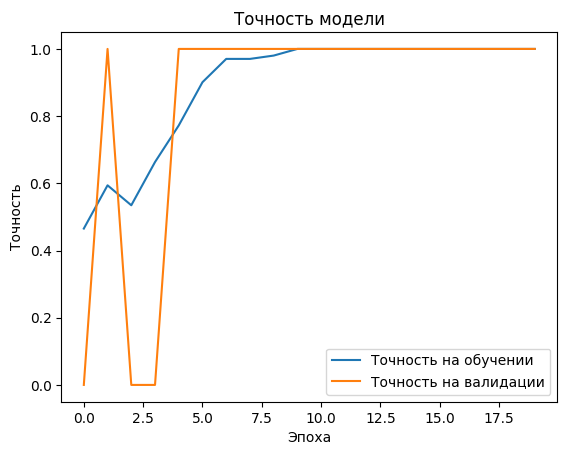

In [18]:
loss, acc = model.evaluate(test_dataset)
print(f"🎯 Точность на тестовой выборке: {acc:.2%}")

# График точности
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.legend()
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.show()